<a href="https://colab.research.google.com/github/Swag-Pseudopy/LLMs-Flow-matching-and-more/blob/main/BFS_Game_of_24_ToT_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎮 Tree-of-Thoughts (ToT) for Game of 24 — Groq API (Colab Notebook)

This Colab notebook implements the **Game of 24** using the **Tree-of-Thoughts (ToT)** framework (BFS search + LLM-based propose + value evaluation), inspired by the *Tree of Thoughts: Deliberate Problem Solving with Large Language Models* paper.

It is designed to be:
- **One-cell runnable**
- **Groq API based**
- **Verbose / traceable** (prints the full ToT search trace)
- **Strictly consistent** across steps: the `left:` numbers at each step are *exactly* the remaining numbers after applying the operation.

---

## ✅ What is Game of 24?

Given **4 numbers**, you must use:
- `+`, `-`, `*`, `/`
- each number **exactly once**
- parentheses allowed implicitly by stepwise reduction

to obtain **24**.

Example:

(10 - 4) * (13 - 9) = 24
---

## 🌳 What is Tree-of-Thoughts (ToT) here?

Instead of generating one long chain-of-thought, we do a **tree search**:

### Each node/state contains:
- Remaining numbers (e.g. `4 4 10`)
- A list of intermediate steps taken so far

### Each depth step:
1. **Propose** multiple candidate next moves (LLM)
2. **Validate** them strictly
3. **Evaluate** each candidate state (LLM → sure/maybe/impossible)
4. **Prune** low-value states
5. Keep only the top-`B` states (BFS)

---

## 🔍 Thought Decomposition (24-game specific)

We decompose reasoning into **3 steps** (depth `T = 3`):

- Step 1: combine 2 numbers → 3 numbers remain  
- Step 2: combine 2 numbers → 2 numbers remain  
- Step 3: combine 2 numbers → 1 number remains (goal = 24)

Example trace format:
```

13 - 9 = 4 (left: 4 4 10)
10 - 4 = 6 (left: 4 6)
4 * 6 = 24 (left: 24)

```

---

## 🧠 LLM Roles in ToT

### 1) Thought Generation: `PROPOSE`
The LLM proposes `K` next steps in the strict format:
```

a op b = c (left: ...)

```

### 2) Thought Evaluation: `VALUE`
The LLM judges a state as:
- `sure`      → likely solvable
- `maybe`     → uncertain
- `impossible`→ should be pruned

We sample the value judgment multiple times (`VALUE_SAMPLES`) and average scores.

---

## ✂️ Pruning and Why It Matters

### Problem observed without pruning:
- Repeated candidate states flood the search
- “Impossible” paths may continue till the end

### Fixes included in this notebook:
✅ **Hard pruning** using `V_THRESHOLD`  
States with average score ≤ threshold are removed.

✅ **Deduplication**  
States with identical remaining numbers are merged (we keep the best one).

---

## ⚙️ Configuration Parameters

You can tune these in the cell:

| Parameter | Meaning | Typical value |
|----------|---------|---------------|
| `T` | Depth (steps) | `3` |
| `K` | Proposals per state | `8` |
| `B` | BFS breadth (kept per depth) | `5` |
| `VALUE_SAMPLES` | value votes per candidate | `3` |
| `V_THRESHOLD` | hard pruning threshold | `0.5` |
| `MODEL_CANDIDATES` | fallback Groq model list | multiple |

### Recommended settings
- Fast run: `llama-3.1-8b-instant`
- Stronger reasoning: `llama-3.3-70b-versatile`

---

## 🔑 Groq API Key Setup (Colab Secrets)

This notebook expects your API key to be stored in **Colab Secrets**:

1. Open **Colab**
2. Left sidebar → **Secrets**
3. Add a secret named exactly:
```

GROQ_API_KEY

````
4. Paste your key as the value

The code automatically loads it via:
```python
from google.colab import userdata
userdata.get("GROQ_API_KEY")
````

---

## 🧾 Output Format (What gets printed)

At runtime, the notebook prints a full ToT trace:

### Per depth:

* Frontier states (current best candidates)
* Proposed steps from each frontier state
* Candidate evaluations (votes + avg score)
* Pruning summary
* Final selected top states

### Final output:

A valid 3-step reduction ending in:

```
(left: 24)
```

---

## ✅ Correctness Guarantees

This implementation **strictly validates** each proposed line:

A proposed line is accepted only if:

1. `a` and `b` exist in the current remaining multiset
2. `c == a op b` exactly (using fractions for precision)
3. The `left:` list exactly matches the computed remaining numbers

If the LLM outputs invalid lines, we fall back to a guaranteed enumeration of all legal moves.

---

## 🧪 Running Examples / Custom Input

The notebook provides a few examples:

* `[4, 9, 10, 13]` (classic)
* `[1, 3, 4, 6]`
* `[2, 7, 8, 9]`
* `[5, 5, 5, 1]`

It also supports **custom input**:

```
custom
4 4 10 13
```

---

## 🧠 Notes / Known Limitations

* LLM evaluation (`sure/maybe/impossible`) is a **heuristic**, not a proof.
* Some solvable states may be wrongly labeled “impossible” → pruning too aggressively can reduce success.

  * If you see this, lower pruning strictness:

    * set `V_THRESHOLD = 0.0`
* Some states can be solvable but require tricky fractions; the strict validator supports fractions.

---

## 📎 Credits

* Tree-of-Thoughts idea: *Yao et al., NeurIPS 2023*
* Implementation: Colab + Groq API + BFS ToT search

---

## 📤 Sharing as GitHub Gist

To share this notebook:

1. Save the notebook (`.ipynb`)
2. Create a GitHub Gist
3. Paste this markdown in the notebook (as a Markdown cell)
4. Share the Gist link


In [6]:
!pip -q install groq
!pip -q install networkx matplotlib

import re
from dataclasses import dataclass, field
from typing import List, Tuple, Optional
from fractions import Fraction

# ---- Colab Secrets -> env ----
try:
    from google.colab import userdata
    groq_key = userdata.get("GROQ_API_KEY")
except Exception:
    groq_key = None

if not groq_key:
    raise ValueError(
        "❌ Could not read GROQ_API_KEY from Colab Secrets.\n"
        "Go to: Colab left panel → Secrets → add GROQ_API_KEY"
    )

from groq import Groq
client = Groq(api_key=groq_key)

import networkx as nx
import matplotlib.pyplot as plt

# Global search tree
SEARCH_TREE = nx.DiGraph()

NODE_COUNTER = 0
EXPLORED_NODES = 0

# ---------------------------
# CONFIG
# ---------------------------
TEMPERATURE = 0.7

T = 3
K = 8
B = 5
VALUE_SAMPLES = 3

OPS = ["+", "-", "*", "/"]

# Try multiple Groq models (handles deprecations)
MODEL_CANDIDATES = [
    "llama-3.3-70b-versatile",
    "llama-3.1-8b-instant",
    "mixtral-8x7b-32768",
    "gemma2-9b-it",
]

# ---------------------------
# Helpers
# ---------------------------
def frac_to_str(x: Fraction) -> str:
    return str(x.numerator) if x.denominator == 1 else f"{x.numerator}/{x.denominator}"

def normalize_nums(nums: List[Fraction]) -> List[Fraction]:
    return sorted(nums, key=lambda z: (float(z), z.numerator, z.denominator))

def str_to_frac(s: str) -> Fraction:
    s = s.strip()
    if "/" in s:
        p, q = s.split("/")
        return Fraction(int(p), int(q))
    return Fraction(int(s), 1)

def apply_op(a: Fraction, b: Fraction, op: str) -> Optional[Fraction]:
    if op == "+": return a + b
    if op == "-": return a - b
    if op == "*": return a * b
    if op == "/":
        if b == 0: return None
        return a / b
    return None

@dataclass
class State:
    nums: List[Fraction]
    steps: List[str] = field(default_factory=list)
    node_id: int = -1
    parent_id: int = -1

def is_goal(nums: List[Fraction]) -> bool:
    return len(nums) == 1 and nums[0] == 24

def register_node(state: State, depth: int):
    global NODE_COUNTER, EXPLORED_NODES

    NODE_COUNTER += 1
    state.node_id = NODE_COUNTER

    SEARCH_TREE.add_node(
        state.node_id,
        nums=[frac_to_str(x) for x in normalize_nums(state.nums)],
        depth=depth
    )

    if state.parent_id != -1:
        SEARCH_TREE.add_edge(state.parent_id, state.node_id)

    EXPLORED_NODES += 1

# ---------------------------
# Model auto-fallback chat
# ---------------------------
def groq_chat(prompt: str) -> Tuple[str, str]:
    last_err = None
    for model in MODEL_CANDIDATES:
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=TEMPERATURE,
            )
            return resp.choices[0].message.content.strip(), model
        except Exception as e:
            last_err = e
            continue
    raise RuntimeError(f"❌ All Groq model candidates failed. Last error:\n{last_err}")

# ---------------------------
# Few-shot examples (SOLVED)
# ---------------------------
# These examples are ONLY for teaching the formatting and the "left:" correctness.
PROPOSE_EXAMPLE = """
Examples:
1. Remaining numbers: 4 9 10 13
Possible next steps:
13 - 9 = 4 (left: 4 4 10)
10 - 4 = 6 (left: 4 6)
4 * 6 = 24 (left: 24)
2. Remaining numbers: 3 3 8 8
Possible next steps:
8 / 3 = 8/3 (left: 8/3 3 8)
3 - 8/3 = 1/3 (left: 1/3 8)
8 / 1/3 = 24 (left: 24)
3. Remaining numbers: 1 2 3 4
Possible next steps:
1 * 2 = 2 (left: 2 3 4)
2 * 3 = 6 (left: 6 4)
4 * 6 = 24 (left: 24)
4. Remaining numbers: 5 5 5 1
Possible next steps:
1 / 5 = 1/5 (left: 1/5 5 5)
5 - 1/5 = 24/5 (left: 24/5 5)
24/5 * 5 = 24 (left: 24)
5. Remaining numbers: 4 4 10 13
Possible next steps:
4 / 4 = 1 (left: 1 10 13)
10 + 13 = 23 (left: 23 1)
23 + 1 = 24 (left: 24)
6. Remaining numbers: 2 7 8 3
Possible next steps:
8 / 3 = 8/3 (left: 8/3 2 7)
2 + 7 = 9 (left: 9 8/3)
9 * 8/3 = 24 (left: 24)
""".strip()

VALUE_EXAMPLE = """
Example evaluations:
Remaining numbers: 4 6
sure

Remaining numbers: 3 8
sure

Remaining numbers: 9 8/3
sure

Remaining numbers: 1 1 1
impossible

Remaining numbers: 3 8 8
maybe
""".strip()

# ---------------------------
# Prompts (with examples)
# ---------------------------
def propose_prompt(nums: List[Fraction], k: int) -> str:
    nums_str = " ".join(frac_to_str(x) for x in nums)
    return f"""
You are playing the Game of 24.
Goal: use +, -, *, / to reach 24.

{PROPOSE_EXAMPLE}

Now propose {k} DIFFERENT valid next steps.

Remaining numbers: {nums_str}

Each next step MUST:
- pick exactly two numbers from the remaining numbers
- apply one operation (+,-,*,/)
- produce the result
- show the remaining numbers after the step

Return EXACTLY {k} lines, each in this format:
a op b = c (left: n1 n2 n3 ...)

Rules:
- "left:" must be the exact remaining multiset after using a and b and adding c
- Use integers or fractions like 3/2
- No extra text, no numbering, no explanations
""".strip()

def value_prompt(nums: List[Fraction]) -> str:
    nums_str = " ".join(frac_to_str(x) for x in nums)
    return f"""
You are evaluating a partial Game of 24 state.

{VALUE_EXAMPLE}

Now evaluate this state:
Remaining numbers: {nums_str}

Classify reachability of 24:
- sure
- maybe
- impossible

Output ONLY ONE WORD: sure, maybe, or impossible.
""".strip()

# ---------------------------
# STRICT Parsing + Validation
# ---------------------------
STEP_RE = re.compile(
    r"^\s*([-\d/]+)\s*([\+\-\*/])\s*([-\d/]+)\s*=\s*([-\d/]+)\s*\(left:\s*([-\d/\s]+)\)\s*$"
)

def parse_left_list(left_str: str) -> List[Fraction]:
    toks = [t for t in left_str.strip().split() if t.strip()]
    return [str_to_frac(t) for t in toks]

def multiset_remove_once(lst: List[Fraction], item: Fraction) -> Optional[List[Fraction]]:
    tmp = lst.copy()
    try:
        tmp.remove(item)
        return tmp
    except ValueError:
        return None

def validate_step_line(curr_nums: List[Fraction], line: str) -> Optional[Tuple[str, List[Fraction]]]:
    m = STEP_RE.match(line.strip())
    if not m:
        return None

    a_s, op, b_s, c_s, left_s = m.groups()
    a, b, c = str_to_frac(a_s), str_to_frac(b_s), str_to_frac(c_s)

    tmp = multiset_remove_once(curr_nums, a)
    if tmp is None: return None
    tmp = multiset_remove_once(tmp, b)
    if tmp is None: return None

    out = apply_op(a, b, op)
    if out is None: return None
    if out != c: return None

    new_nums = tmp + [out]
    claimed_left = parse_left_list(left_s)

    if normalize_nums(claimed_left) != normalize_nums(new_nums):
        return None

    left_fmt = " ".join(frac_to_str(x) for x in normalize_nums(new_nums))
    step_fmt = f"{frac_to_str(a)} {op} {frac_to_str(b)} = {frac_to_str(out)} (left: {left_fmt})"
    return step_fmt, new_nums

def enumerate_all_valid_moves(nums: List[Fraction]) -> List[Tuple[str, List[Fraction]]]:
    results = []
    n = len(nums)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            a, b = nums[i], nums[j]
            rest = [nums[k] for k in range(n) if k not in (i, j)]
            for op in OPS:
                out = apply_op(a, b, op)
                if out is None:
                    continue
                new_nums = rest + [out]
                left_fmt = " ".join(frac_to_str(x) for x in normalize_nums(new_nums))
                step_fmt = f"{frac_to_str(a)} {op} {frac_to_str(b)} = {frac_to_str(out)} (left: {left_fmt})"
                results.append((step_fmt, new_nums))

    # dedupe
    seen = set()
    uniq = []
    for step, new_nums in results:
        key = (tuple(normalize_nums(new_nums)), step.split(" (left:")[0])
        if key in seen:
            continue
        seen.add(key)
        uniq.append((step, new_nums))
    return uniq

# ---------------------------
# ToT-BFS with full trace
# ---------------------------
def label_score(label: str) -> float:
    lab = label.strip().lower()
    if "sure" in lab: return 2.0
    if "maybe" in lab: return 1.0
    if "impossible" in lab: return 0.0
    return 1.0

def tot_bfs_24(start_nums: List[int]) -> Optional[State]:
    frontier = [State(nums=[Fraction(x,1) for x in start_nums], steps=[])]
    register_node(frontier[0], depth=0)
    print("\n" + "="*90)
    print("🎮 Game of 24 — Tree of Thoughts (BFS) via GROQ (few-shot prompts)")
    print(f"Start: {start_nums}")
    print(f"Config: T={T}, K={K}, B={B}, VALUE_SAMPLES={VALUE_SAMPLES}")
    print("Model candidates:", MODEL_CANDIDATES)
    print("="*90)

    for depth in range(1, T+1):
        print("\n" + "="*90)
        print(f"🌳 DEPTH {depth}/{T} | Frontier size: {len(frontier)}")
        for i, st in enumerate(frontier):
            print(f"  Frontier[{i}] nums = {[frac_to_str(x) for x in normalize_nums(st.nums)]}")
            if st.steps:
                print("    Steps so far:")
                for s in st.steps:
                    print("     -", s)

        candidates: List[State] = []
        print("\n" + "-"*90)
        print("🔎 EXPAND (PROPOSE THOUGHTS)")

        for fi, st in enumerate(frontier):
            raw, model_used = groq_chat(propose_prompt(st.nums, K))
            # print("Here:", raw)
            # exit()
            lines = [ln.strip() for ln in raw.split("\n") if ln.strip()]

            print("\n" + "-"*90)
            print(f"[From Frontier[{fi}]] nums = {[frac_to_str(x) for x in normalize_nums(st.nums)]}")
            print(f"Model used: {model_used}")
            print("LLM proposed steps:")
            for ln in lines:
                print("  >", ln)

            valid_moves = []
            for ln in lines:
                ok = validate_step_line(st.nums, ln)
                if ok is not None:
                    valid_moves.append(ok)

            if len(valid_moves) == 0:
                print("⚠️  No STRICT-valid steps parsed from LLM. Falling back to exact enumeration.")
                valid_moves = enumerate_all_valid_moves(st.nums)

            for step_str, new_nums in valid_moves[:K]:
                child = State(nums=new_nums, steps=st.steps + [step_str])
                child.parent_id = st.node_id
                register_node(child, depth)
                candidates.append(child)

        print("\n" + "="*90)
        print(f"🧠 EVALUATE {len(candidates)} candidate states (sure/maybe/impossible)")

        scored: List[Tuple[float, State, List[str]]] = []
        for ci, cand in enumerate(candidates):
            labels = []
            total = 0.0
            used_models = []

            for _ in range(VALUE_SAMPLES):
                lab, model_used = groq_chat(value_prompt(cand.nums))
                labels.append(lab.strip().lower())
                used_models.append(model_used)
                total += label_score(lab)

            avg = total / VALUE_SAMPLES
            scored.append((avg, cand, labels))

            print("\n" + "-"*90)
            print(f"Candidate[{ci}] nums = {[frac_to_str(x) for x in normalize_nums(cand.nums)]}")
            print("Steps:")
            for s in cand.steps:
                print("  -", s)
            print("Value votes:", labels, f"=> avg_score={avg:.3f}")
            print("Models used (value):", used_models)

        scored.sort(key=lambda x: x[0], reverse=True)
        frontier = [st for _, st, _ in scored[:B]]

        print("\n" + "="*90)
        print(f"✂️ PRUNE -> Keeping top B={B} states")
        for i, st in enumerate(frontier):
            print(f"  Kept[{i}] nums = {[frac_to_str(x) for x in normalize_nums(st.nums)]}")
            print(f"    Last step: {st.steps[-1]}")

        for st in frontier:
            if is_goal(st.nums):
                print("\n" + "🎉"*30)
                print("SOLVED!")
                return st

    for st in frontier:
        if is_goal(st.nums):
            return st
    return None

# ---------------------------
# Examples + Custom entry
# ---------------------------
EXAMPLES = {
    "1) Example": [4, 9, 10, 13],
    "2) Example": [1, 3, 4, 6],
    "3) Example": [2, 7, 8, 3],     # (8 - 2) * (7 - 3) = 8/3 * (7 + 2)= 24
    "4) Example": [5, 5, 5, 1],
}

print("Available examples:")
for name, nums in EXAMPLES.items():
    print(f"  {name}: {nums}")

print("\nChoose one:")
print("  - Enter 1/2/3/4 for an example")
print("  - OR type 'custom' to enter your own 4 numbers")

choice = input("\nYour choice: ").strip().lower()

if choice == "custom":
    raw = input("Enter 4 numbers separated by spaces (e.g. 4 9 10 13): ").strip()
    parts = raw.split()
    if len(parts) != 4:
        raise ValueError("❌ Please enter exactly 4 numbers.")
    start = [int(x) for x in parts]
else:
    idx = int(choice)
    if idx not in [1,2,3,4]:
        raise ValueError("❌ Invalid choice.")
    start = list(EXAMPLES.values())[idx-1]

# ---------------------------
# RUN
# ---------------------------
solution = tot_bfs_24(start)

print("\n" + "="*90)
print("📌 FINAL OUTPUT")
if solution is None:
    print("No solution found with current search budget.")
else:
    for s in solution.steps:
        print(s)
    print("Final:", frac_to_str(solution.nums[0]))
print("="*90)

print("\nSearch Statistics")
print("-----------------")
print("Nodes explored:", EXPLORED_NODES)
print("Total nodes in tree:", SEARCH_TREE.number_of_nodes())
print("Total edges:", SEARCH_TREE.number_of_edges())

Available examples:
  1) Example: [4, 9, 10, 13]
  2) Example: [1, 3, 4, 6]
  3) Example: [2, 7, 8, 3]
  4) Example: [5, 5, 5, 1]

Choose one:
  - Enter 1/2/3/4 for an example
  - OR type 'custom' to enter your own 4 numbers

Your choice: 3

🎮 Game of 24 — Tree of Thoughts (BFS) via GROQ (few-shot prompts)
Start: [2, 7, 8, 3]
Config: T=3, K=8, B=5, VALUE_SAMPLES=3
Model candidates: ['llama-3.3-70b-versatile', 'llama-3.1-8b-instant', 'mixtral-8x7b-32768', 'gemma2-9b-it']

🌳 DEPTH 1/3 | Frontier size: 1
  Frontier[0] nums = ['2', '3', '7', '8']

------------------------------------------------------------------------------------------
🔎 EXPAND (PROPOSE THOUGHTS)

------------------------------------------------------------------------------------------
[From Frontier[0]] nums = ['2', '3', '7', '8']
Model used: llama-3.1-8b-instant
LLM proposed steps:
  > 8 / 3 = 8/3 (left: 2 7 3)
  > 7 + 2 = 9 (left: 9 8/3)
  > 9 * 8/3 = 24 (left: 24)
  > 7 - 2 = 5 (left: 5 8/3)
  > 8 / 5 = 8/5 (left: 5 

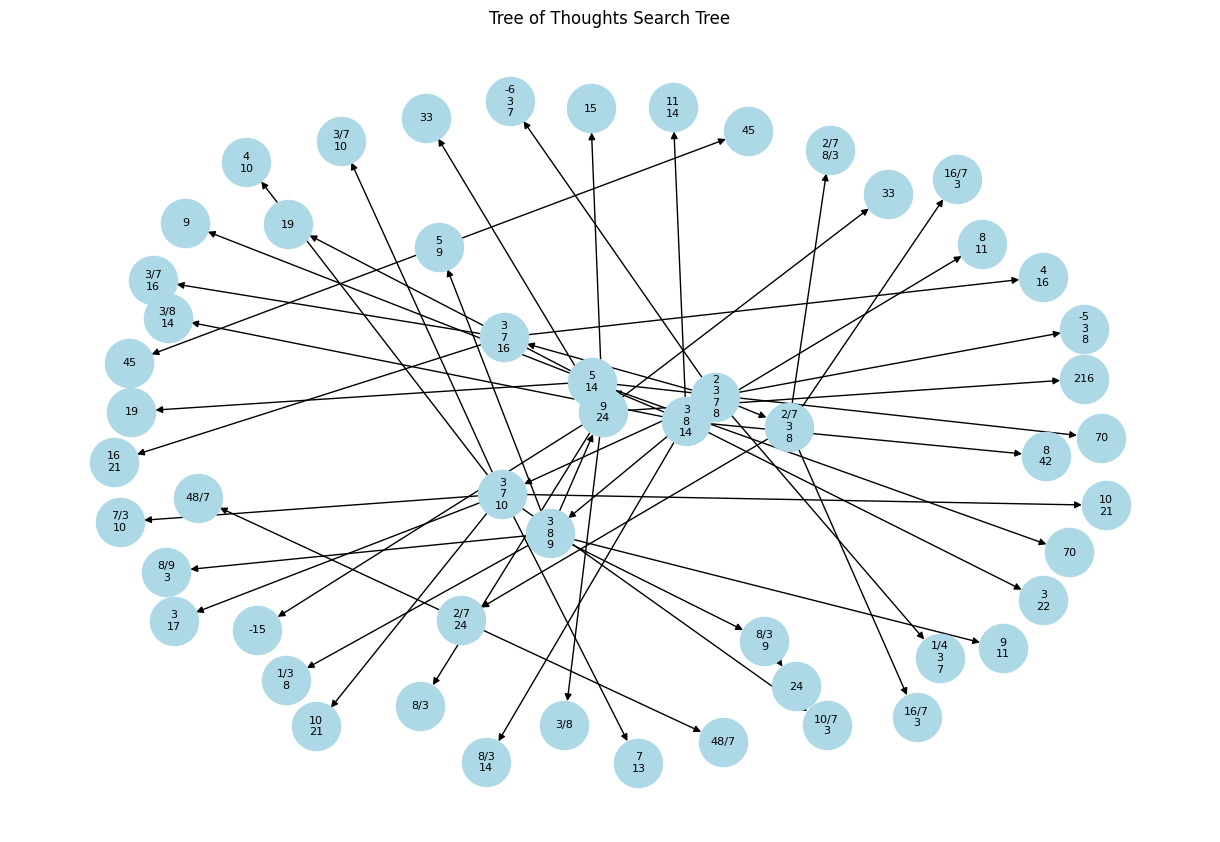

In [7]:
def plot_search_tree():

    plt.figure(figsize=(12,8))

    pos = nx.spring_layout(SEARCH_TREE)

    labels = {}
    for node in SEARCH_TREE.nodes():
        nums = SEARCH_TREE.nodes[node]['nums']
        labels[node] = "\n".join(nums)

    nx.draw(
        SEARCH_TREE,
        pos,
        with_labels=True,
        labels=labels,
        node_size=1200,
        node_color="lightblue",
        font_size=8
    )

    plt.title("Tree of Thoughts Search Tree")
    plt.show()

plot_search_tree()